In [15]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [9]:
base_dir = Path(r'E:\NYISO_Project\dataset')

In [10]:
X_train = np.load(base_dir / 'X_train.npy')
y_train = np.load(base_dir / 'y_train.npy')
X_val = np.load(base_dir / 'X_val.npy')
y_val = np.load(base_dir / 'y_val.npy')

In [2]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [11]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))  # Add dropout to prevent overfitting
model.add(LSTM(64))
model.add(Dropout(0.2))  # Add dropout to prevent overfitting
model.add(Dense(1))  # Output layer for regression
model.compile(optimizer='adam', loss='mean_squared_error')

c:\Users\ASUS\anaconda3\envs\almamun\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
# Model training
history = model.fit(X_train, y_train, epochs=20, batch_size=64, 
                    validation_data=(X_val, y_val), callbacks=[early_stop], verbose=1)

Epoch 1/20
822/822 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 0.0751 - val_loss: 0.0161
Epoch 2/20
822/822 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 0.0171 - val_loss: 0.0063
Epoch 3/20
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.0128 - val_loss: 0.0053
Epoch 4/20
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.0115 - val_loss: 0.0064
Epoch 5/20
822/822 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - loss: 0.0110 - val_loss: 0.0046
Epoch 6/20
822/822 ━━━━━━━━━━━━━━━━━━━━ 83s 95ms/step - loss: 0.0106 - val_loss: 0.0043
Epoch 7/20
822/822 ━━━━━━━━━━━━━━━━━━━━ 66s 80ms/step - loss: 0.0100 - val_loss: 0.0041
Epoch 8/20
822/822 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 0.0100 - val_loss: 0.0048
Epoch 9/20
822/822 ━━━━━━━━━━━━━━━━━━━━ 57s 69ms/step - loss: 0.0096 - val_loss: 0.0042
Epoch 10/20
822/822 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - loss: 0.0096 - val_loss: 0.0038
Epoch 11/20
822/822 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.0094 - val_loss: 0.0043
Epoch 12/20
822/822 ━━━━━━━━━━

Text(0, 0.5, 'Mean Squared Error')

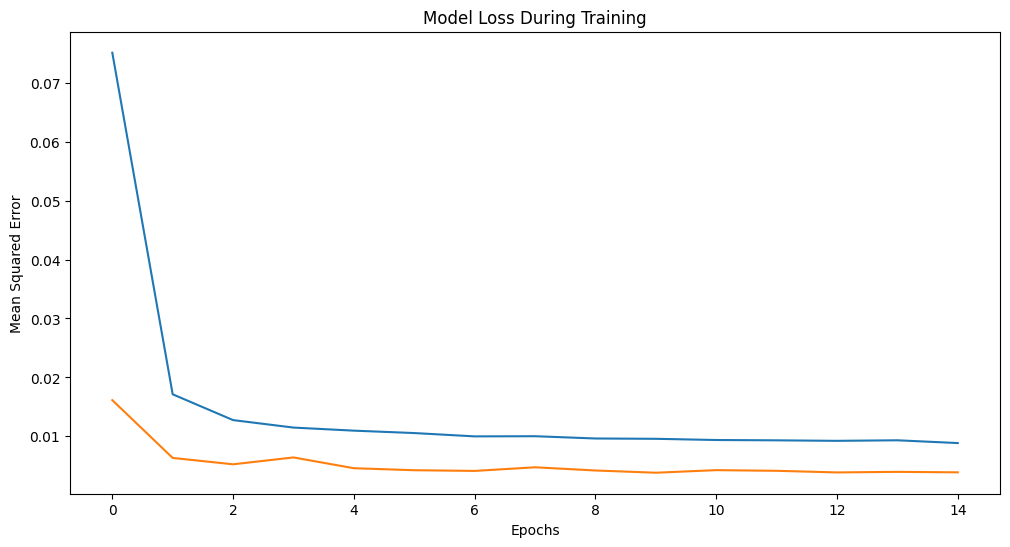

In [16]:
# Validation of the model
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')

In [17]:
# Saving the trained model for future use
model.save(r'E:\NYISO_Project\models\load_forecasting.keras')